# 8-Puzzle Problem — Uninformed Search Algorithms

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/chebil/AI-course-book/blob/main/chapters/ch02_uninformed.ipynb)

## Overview

The **8-puzzle** is a classic AI problem consisting of a 3×3 grid with tiles numbered 1–8 and one blank space.  
The goal is to slide tiles until the board matches the **goal configuration**.

```
Initial State       Goal State
┌───┬───┬───┐      ┌───┬───┬───┐
│ 1 │ 2 │ 5 │      │ 1 │ 2 │ 3 │
├───┼───┼───┤  →   ├───┼───┼───┤
│ 3 │ 4 │   │      │ 4 │ 5 │ 6 │
├───┼───┼───┤      ├───┼───┼───┤
│ 6 │ 7 │ 8 │      │ 7 │ 8 │   │
└───┴───┴───┘      └───┴───┴───┘
```

### Algorithms Covered
| Algorithm | Strategy | Complete | Optimal | Space |
|-----------|-----------|----------|---------|-------|
| **BFS** | Level-by-level (FIFO) | ✅ Yes | ✅ Yes | Exponential |
| **DFS** | Depth-first (LIFO) | ⚠️ With limit | ❌ No | Linear |
| **UCS** | Lowest cost first | ✅ Yes | ✅ Yes | Exponential |


In [1]:
# Install required packages (run once)
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "ipywidgets", "matplotlib", "--quiet"], check=False)
print("Dependencies ready.")


Dependencies ready.


In [2]:
import heapq
import time
import sys
from collections import deque
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import ipywidgets as widgets
from IPython.display import display, clear_output
import warnings
warnings.filterwarnings("ignore")

print("All imports successful ✓")


All imports successful ✓


---
## Part 1 — State Representation & Puzzle Core

A state is represented as a **tuple of 9 integers**, read row-by-row (left-to-right, top-to-bottom).  
`0` represents the blank tile.

```
State tuple:  (1, 2, 5, 3, 4, 0, 6, 7, 8)
Board layout:
  1  2  5
  3  4  _
  6  7  8
```

**Moves** are defined by how the blank (index of `0`) can swap with adjacent tiles:

| Move | Blank shifts by | Valid when |
|------|-----------------|------------|
| Up   | −3              | row > 0    |
| Down | +3              | row < 2    |
| Left | −1              | col > 0    |
| Right| +1              | col < 2    |


In [3]:
# ─── Puzzle Core ──────────────────────────────────────────────────────────────

GOAL_STATE = (1, 2, 3, 4, 5, 6, 7, 8, 0)

MOVES = {
    "Up":    -3,
    "Down":  +3,
    "Left":  -1,
    "Right": +1,
}

def is_goal(state):
    """Return True if state matches the goal."""
    return state == GOAL_STATE

def get_blank(state):
    """Return the (row, col) position of the blank tile."""
    idx = state.index(0)
    return idx // 3, idx % 3

def get_neighbors(state):
    """
    Generate all valid successor states together with the move name and step cost.
    Returns a list of (move_name, new_state, cost) tuples.
    """
    row, col = get_blank(state)
    blank = row * 3 + col
    neighbors = []

    moves_valid = []
    if row > 0: moves_valid.append(("Up",    MOVES["Up"]))
    if row < 2: moves_valid.append(("Down",  MOVES["Down"]))
    if col > 0: moves_valid.append(("Left",  MOVES["Left"]))
    if col < 2: moves_valid.append(("Right", MOVES["Right"]))

    for move_name, delta in moves_valid:
        lst = list(state)
        lst[blank], lst[blank + delta] = lst[blank + delta], lst[blank]
        neighbors.append((move_name, tuple(lst), 1))   # uniform cost = 1

    return neighbors

def print_state(state, label=""):
    """Pretty-print a puzzle state."""
    if label:
        print(f"  {label}")
    for i in range(0, 9, 3):
        row = ""
        for v in state[i:i+3]:
            row += f"  {v if v != 0 else '_'}"
        print(row)
    print()

def reconstruct_path(came_from, start, goal):
    """Reconstruct the sequence of (move, state) from start to goal."""
    path = []
    state = goal
    while state != start:
        move, prev = came_from[state]
        path.append((move, state))
        state = prev
    path.reverse()
    return path

# ── Quick sanity check ────────────────────────────────────────────────────────
sample = (1, 2, 5, 3, 4, 0, 6, 7, 8)
print_state(sample, label="Sample initial state")
print("Blank at:", get_blank(sample))
print("Neighbors:")
for mv, ns, c in get_neighbors(sample):
    print(f"  Move {mv:5s} → {ns}")


  Sample initial state
  1  2  5
  3  4  _
  6  7  8

Blank at: (1, 2)
Neighbors:
  Move Up    → (1, 2, 0, 3, 4, 5, 6, 7, 8)
  Move Down  → (1, 2, 5, 3, 4, 8, 6, 7, 0)
  Move Left  → (1, 2, 5, 3, 0, 4, 6, 7, 8)


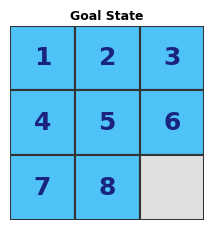

In [4]:
# ─── Visualization Helper ─────────────────────────────────────────────────────

def draw_state(ax, state, title="", highlight=None):
    """Draw a single puzzle state as a grid on a matplotlib Axes."""
    ax.set_xlim(0, 3)
    ax.set_ylim(0, 3)
    ax.set_aspect("equal")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=9, pad=4, fontweight="bold")

    for idx, val in enumerate(state):
        r, c = idx // 3, idx % 3
        y = 2 - r   # flip so row 0 is at top

        if val == 0:
            color = "#e0e0e0"
            txt = ""
        elif highlight and idx in highlight:
            color = "#ffd54f"
            txt = str(val)
        else:
            color = "#4fc3f7"
            txt = str(val)

        rect = plt.Rectangle([c, y], 1, 1, linewidth=1.5,
                              edgecolor="#333", facecolor=color)
        ax.add_patch(rect)
        if txt:
            ax.text(c + 0.5, y + 0.5, txt,
                    ha="center", va="center",
                    fontsize=18, fontweight="bold", color="#1a237e")

def draw_path(path, start, title="Solution Path", max_show=12):
    """Visualise the solution path as a row of puzzle states."""
    states = [start] + [s for _, s in path]
    moves  = ["Start"] + [m for m, _ in path]

    if len(states) > max_show:
        states = states[:max_show]
        moves  = moves[:max_show]
        truncated = True
    else:
        truncated = False

    n = len(states)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.0, 2.8))
    if n == 1:
        axes = [axes]
    fig.suptitle(title, fontsize=11, fontweight="bold", y=1.02)

    for i, (ax, state, move) in enumerate(zip(axes, states, moves)):
        draw_state(ax, state, title=f"[{i}] {move}")
        if i > 0:
            ax.annotate("", xy=(-0.15, 0.5), xycoords="axes fraction",
                        xytext=(0.0, 0.5),
                        arrowprops=dict(arrowstyle="<-", color="gray", lw=1.5))

    if truncated:
        fig.text(0.99, -0.05,
                 f"(showing first {max_show} of {len(path)+1} steps)",
                 ha="right", fontsize=8, color="gray")

    plt.tight_layout()
    plt.show()

# ── Demo using sample state ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(2.4, 2.4))
draw_state(ax, GOAL_STATE, title="Goal State")
plt.tight_layout()
plt.show()


---
## Part 2 — Breadth-First Search (BFS)

### How it works
BFS explores states **level by level** using a **FIFO queue**.  
All states at depth $d$ are examined before any state at depth $d+1$.

```
Queue: [start]
while queue not empty:
    node = queue.popleft()        # dequeue from front
    if goal(node): return path
    for each neighbor of node:
        if not visited:
            visited.add(neighbor)
            queue.append(neighbor)
```

**Properties:**
- **Complete** — guaranteed to find a solution if one exists  
- **Optimal** — finds the shallowest (shortest) solution  
- **Time/Space** — $O(b^d)$ where $b$ = branching factor, $d$ = solution depth


In [5]:
# ─── BFS Implementation ───────────────────────────────────────────────────────

def bfs(start):
    """
    Breadth-First Search for the 8-puzzle.

    Parameters
    ----------
    start : tuple  – initial puzzle state (9-element tuple, 0 = blank)

    Returns
    -------
    dict with keys:
        path          – list of (move, state) from start to goal
        nodes_expanded – number of states dequeued & expanded
        max_frontier   – peak frontier (queue) size
        time_s         – wall-clock seconds
        found          – bool, whether a solution was found
    """
    if is_goal(start):
        return dict(path=[], nodes_expanded=0, max_frontier=1, time_s=0.0, found=True)

    frontier   = deque([start])         # FIFO queue
    visited    = {start}                # closed set
    came_from  = {start: None}         # state → (move, parent_state)

    nodes_expanded = 0
    max_frontier   = 1
    t0             = time.perf_counter()

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        state = frontier.popleft()      # ← FIFO
        nodes_expanded += 1

        for move, neighbor, _ in get_neighbors(state):
            if neighbor not in visited:
                visited.add(neighbor)
                came_from[neighbor] = (move, state)

                if is_goal(neighbor):
                    t1 = time.perf_counter()
                    path = reconstruct_path(came_from, start, neighbor)
                    return dict(path=path, nodes_expanded=nodes_expanded,
                                max_frontier=max_frontier,
                                time_s=round(t1 - t0, 4), found=True)

                frontier.append(neighbor)

    t1 = time.perf_counter()
    return dict(path=[], nodes_expanded=nodes_expanded,
                max_frontier=max_frontier,
                time_s=round(t1 - t0, 4), found=False)


# ── Run BFS on sample puzzle ──────────────────────────────────────────────────
# (1,2,5,3,4,0,6,7,8) has 2 inversions → solvable
START = (1, 2, 5, 3, 4, 0, 6, 7, 8)

print("=== BFS ===")
print_state(START, label="Initial State")

result_bfs = bfs(START)

if result_bfs["found"]:
    print(f"  Solution depth    : {len(result_bfs['path'])} moves")
    print(f"  Nodes expanded    : {result_bfs['nodes_expanded']:,}")
    print(f"  Max frontier size : {result_bfs['max_frontier']:,}")
    print(f"  Time              : {result_bfs['time_s']} s\n")
    print("  Move sequence:", " → ".join(m for m, _ in result_bfs["path"]))
else:
    print("  No solution found.")


=== BFS ===
  Initial State
  1  2  5
  3  4  _
  6  7  8

  Solution depth    : 21 moves
  Nodes expanded    : 49,595
  Max frontier size : 18,252
  Time              : 0.2126 s

  Move sequence: Down → Left → Up → Left → Down → Right → Right → Up → Left → Left → Up → Right → Right → Down → Left → Up → Left → Down → Down → Right → Right


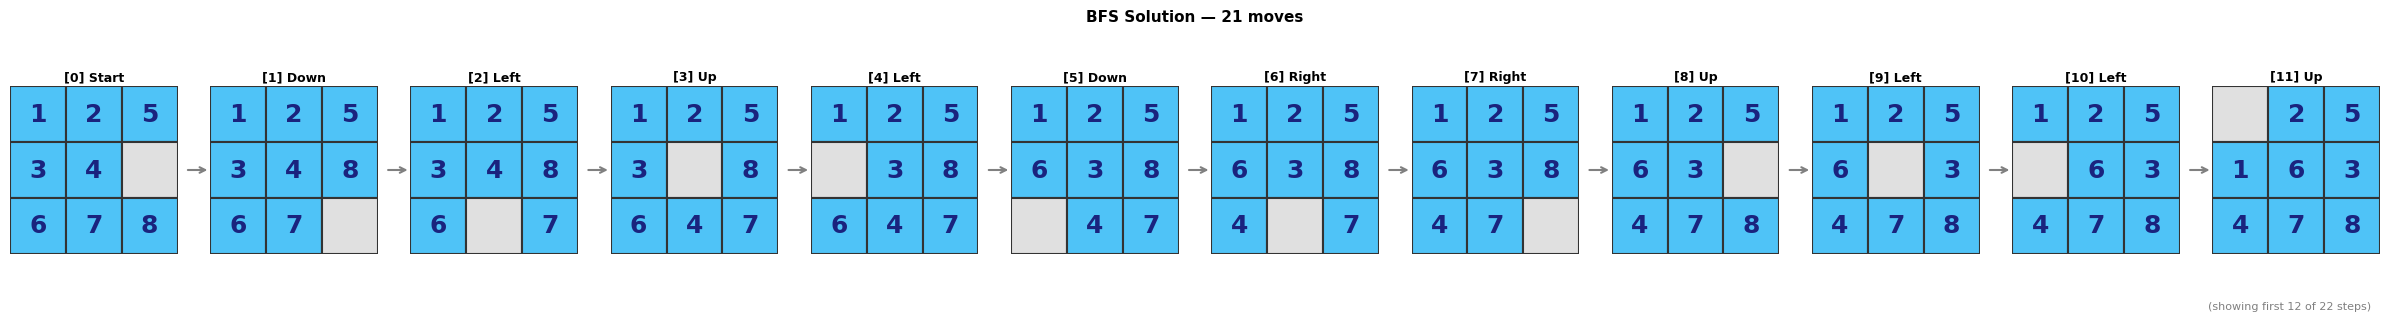

In [6]:
# ─── Visualise BFS path ───────────────────────────────────────────────────────
if result_bfs["found"]:
    draw_path(result_bfs["path"], START, title=f"BFS Solution — {len(result_bfs['path'])} moves")


---
## Part 3 — Depth-First Search (DFS)

### How it works
DFS explores states by diving as **deep as possible** before backtracking.  
It uses a **LIFO stack** and a **depth limit** to avoid infinite loops.

```
Stack: [start]
while stack not empty:
    node, depth = stack.pop()         # pop from top
    if goal(node): return path
    if depth >= limit: continue       # depth cut-off
    for each neighbor of node (reversed):
        if not visited:
            stack.append((neighbor, depth+1))
```

**Properties:**
- **Complete** — only with a depth limit and visited set  
- **Optimal** — ❌ may find a longer path first  
- **Time** — $O(b^m)$ where $m$ = max depth  
- **Space** — $O(b \cdot m)$ — much more memory-efficient than BFS


In [20]:
# ─── DFS Implementation ───────────────────────────────────────────────────────

def dfs(start, depth_limit=150):
    """
    Depth-First Search (with depth limit & visited set) for the 8-puzzle.

    Parameters
    ----------
    start       : tuple – initial state
    depth_limit : int   – maximum search depth (prevents infinite loops)

    Returns
    -------
    Same dict structure as bfs().
    """
    if is_goal(start):
        return dict(path=[], nodes_expanded=0, max_frontier=1, time_s=0.0, found=True)

    # Stack entries: (state, depth, came_from snapshot for this branch)
    # We store came_from globally and overwrite — DFS is not optimal anyway.
    stack      = [(start, 0)]           # LIFO stack
    visited    = {start}
    came_from  = {start: None}

    nodes_expanded = 0
    max_frontier   = 1
    t0             = time.perf_counter()

    while stack:
        max_frontier = max(max_frontier, len(stack))
        state, depth = stack.pop()      # ← LIFO
        nodes_expanded += 1

        if is_goal(state):
            t1 = time.perf_counter()
            path = reconstruct_path(came_from, start, state)
            return dict(path=path, nodes_expanded=nodes_expanded,
                        max_frontier=max_frontier,
                        time_s=round(t1 - t0, 4), found=True)

        if depth >= depth_limit:
            continue                    # depth cut-off

        # Reverse so that "Up" is tried first when popped
        for move, neighbor, _ in reversed(get_neighbors(state)):
            if neighbor not in visited:
                visited.add(neighbor)
                came_from[neighbor] = (move, state)
                stack.append((neighbor, depth + 1))

    t1 = time.perf_counter()
    return dict(path=[], nodes_expanded=nodes_expanded,
                max_frontier=max_frontier,
                time_s=round(t1 - t0, 4), found=False)


# ── Run DFS on sample puzzle ──────────────────────────────────────────────────
print_state(START, label="Initial State")

result_dfs = dfs(START, depth_limit=20000)

if result_dfs["found"]:
    print(f"  Solution depth    : {len(result_dfs['path'])} moves")
    print(f"  Nodes expanded    : {result_dfs['nodes_expanded']:,}")
    print(f"  Max frontier size : {result_dfs['max_frontier']:,}")
    print(f"  Time              : {result_dfs['time_s']} s\n")
    print("  Move sequence:", " → ".join(m for m, _ in result_dfs["path"]))
else:
    print("  No solution found (depth limit reached or unsolvable).")


  Initial State
  1  2  5
  3  4  _
  6  7  8

  Solution depth    : 13439 moves
  Nodes expanded    : 154,415
  Max frontier size : 15,542
  Time              : 0.5273 s

  Move sequence: Up → Left → Down → Down → Left → Up → Up → Right → Down → Down → Left → Up → Up → Right → Down → Down → Left → Up → Up → Right → Down → Down → Left → Up → Up → Right → Down → Down → Left → Up → Right → Up → Left → Down → Down → Right → Up → Up → Left → Down → Down → Right → Up → Up → Right → Down → Down → Left → Up → Up → Left → Down → Down → Right → Up → Up → Left → Down → Down → Right → Up → Up → Left → Down → Down → Right → Up → Up → Left → Down → Down → Right → Up → Up → Left → Down → Right → Up → Left → Down → Down → Right → Up → Up → Left → Down → Down → Right → Up → Up → Right → Down → Down → Left → Up → Up → Left → Down → Down → Right → Up → Up → Left → Down → Down → Right → Up → Up → Left → Down → Down → Right → Up → Up → Left → Down → Down → Right → Up → Up → Left → Down → Right → Up → Left

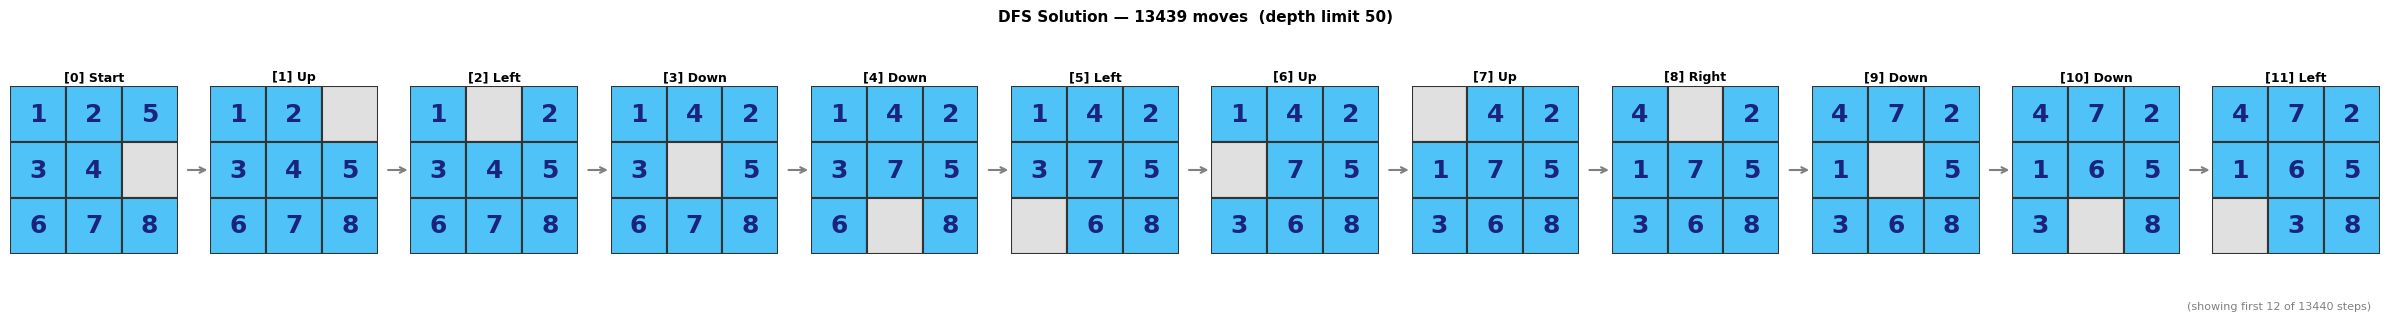

In [21]:
# ─── Visualise DFS path ───────────────────────────────────────────────────────
if result_dfs["found"]:
    draw_path(result_dfs["path"], START,
              title=f"DFS Solution — {len(result_dfs['path'])} moves  (depth limit 50)")
else:
    print("DFS did not find a solution within the depth limit.")


---
## Part 4 — Uniform Cost Search (UCS)

### How it works
UCS always expands the node with the **lowest cumulative path cost** $g(n)$.  
It uses a **min-heap priority queue** ordered by $g(n)$.

```
PQ: [(cost=0, start)]
while PQ not empty:
    cost, node = heappop(PQ)          # cheapest node
    if goal(node): return path
    for each (neighbor, step_cost):
        new_cost = cost + step_cost
        if neighbor not seen or cheaper:
            heappush(PQ, (new_cost, neighbor))
```

Since every step has cost = 1 in the standard 8-puzzle, UCS behaves identically to BFS.  
The implementation below uses **general step costs** so you can experiment with non-uniform costs.

**Properties:**
- **Complete** — yes (positive step costs)  
- **Optimal** — yes, finds minimum-cost solution  
- **Time/Space** — $O(b^{1 + \lfloor C^*/\varepsilon \rfloor})$ where $C^*$ = optimal cost


In [9]:
# ─── UCS Implementation ───────────────────────────────────────────────────────

def ucs(start, cost_fn=None):
    """
    Uniform Cost Search for the 8-puzzle.

    Parameters
    ----------
    start   : tuple – initial state
    cost_fn : callable(move, state) → int, optional
              Custom step-cost function.  Defaults to 1 for every move.

    Returns
    -------
    Same dict structure as bfs().
    """
    if cost_fn is None:
        cost_fn = lambda move, state: 1   # default: uniform cost

    if is_goal(start):
        return dict(path=[], nodes_expanded=0, max_frontier=1, time_s=0.0, found=True)

    # Priority queue entries: (cumulative_cost, tie_breaker, state)
    counter    = 0
    frontier   = [(0, counter, start)]
    heapq.heapify(frontier)

    visited    = {}          # state → best cost seen
    came_from  = {start: None}

    nodes_expanded = 0
    max_frontier   = 1
    t0             = time.perf_counter()

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        g, _, state  = heapq.heappop(frontier)

        # Skip if we already found a cheaper path to this state
        if state in visited and visited[state] < g:
            continue
        visited[state] = g
        nodes_expanded += 1

        if is_goal(state):
            t1 = time.perf_counter()
            path = reconstruct_path(came_from, start, state)
            return dict(path=path, nodes_expanded=nodes_expanded,
                        max_frontier=max_frontier,
                        time_s=round(t1 - t0, 4), found=True,
                        total_cost=g)

        for move, neighbor, _ in get_neighbors(state):
            step  = cost_fn(move, state)
            new_g = g + step
            if neighbor not in visited or visited[neighbor] > new_g:
                came_from[neighbor] = (move, state)
                counter += 1
                heapq.heappush(frontier, (new_g, counter, neighbor))

    t1 = time.perf_counter()
    return dict(path=[], nodes_expanded=nodes_expanded,
                max_frontier=max_frontier,
                time_s=round(t1 - t0, 4), found=False, total_cost=None)


# ── Run UCS on sample puzzle (uniform cost = 1) ───────────────────────────────
print("=== UCS (uniform step cost = 1) ===")
print_state(START, label="Initial State")

result_ucs = ucs(START)

if result_ucs["found"]:
    print(f"  Solution depth    : {len(result_ucs['path'])} moves")
    print(f"  Total path cost   : {result_ucs.get('total_cost', 'N/A')}")
    print(f"  Nodes expanded    : {result_ucs['nodes_expanded']:,}")
    print(f"  Max frontier size : {result_ucs['max_frontier']:,}")
    print(f"  Time              : {result_ucs['time_s']} s\n")
    print("  Move sequence:", " → ".join(m for m, _ in result_ucs["path"]))
else:
    print("  No solution found.")


=== UCS (uniform step cost = 1) ===
  Initial State
  1  2  5
  3  4  _
  6  7  8

  Solution depth    : 21 moves
  Total path cost   : 21
  Nodes expanded    : 105,848
  Max frontier size : 44,729
  Time              : 0.6586 s

  Move sequence: Down → Left → Up → Left → Down → Right → Right → Up → Left → Left → Up → Right → Right → Down → Left → Up → Left → Down → Down → Right → Right


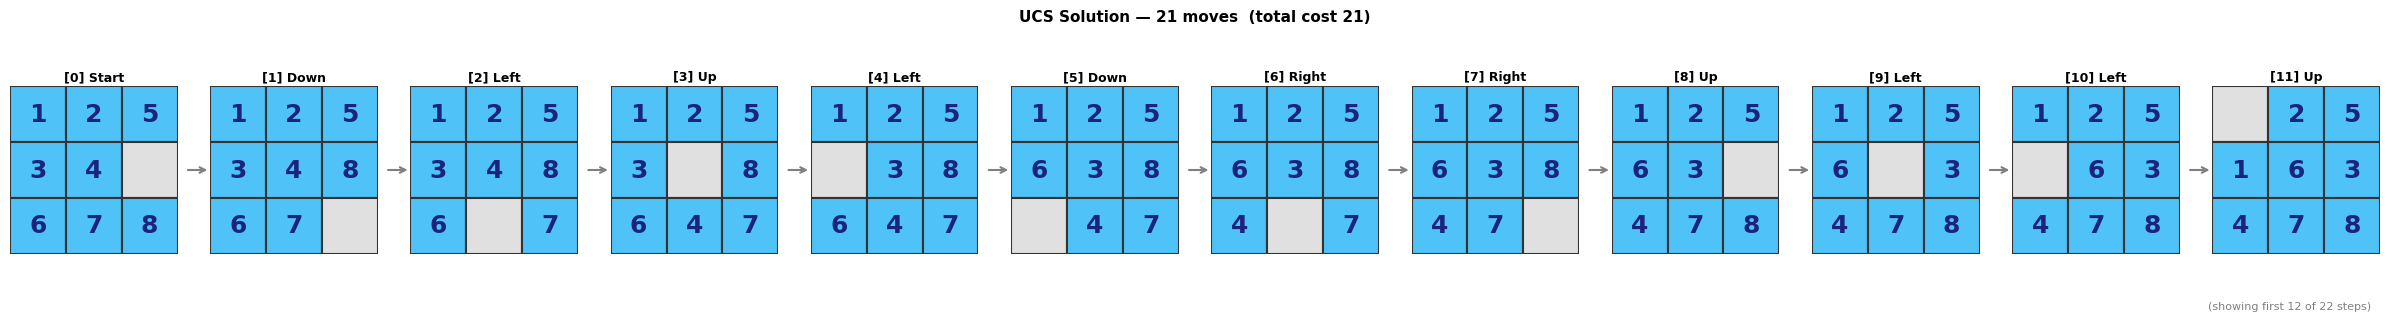

In [10]:
# ─── Visualise UCS path ───────────────────────────────────────────────────────
if result_ucs["found"]:
    draw_path(result_ucs["path"], START,
              title=f"UCS Solution — {len(result_ucs['path'])} moves  (total cost {result_ucs.get('total_cost','-')})")
else:
    print("UCS did not find a solution.")


---
## Part 5 — Interactive Comparison

Use the widget below to:
1. **Enter any starting configuration** (a permutation of 0–8, where 0 = blank)
2. **Choose a DFS depth limit**
3. **Run all three algorithms** and compare results side-by-side

> ⚠️ Not every tile arrangement is solvable. The widget will warn you if your puzzle is unsolvable.


In [11]:
# ─── Solvability checker ──────────────────────────────────────────────────────

def count_inversions(state):
    """Count the number of inversions (ignoring the blank tile)."""
    tiles = [v for v in state if v != 0]
    inv = 0
    for i in range(len(tiles)):
        for j in range(i + 1, len(tiles)):
            if tiles[i] > tiles[j]:
                inv += 1
    return inv

def is_solvable(state):
    """An 8-puzzle is solvable iff the number of inversions is even."""
    return count_inversions(state) % 2 == 0

# ─── Bar chart comparison ─────────────────────────────────────────────────────

def plot_comparison(results, start):
    """Draw a 2×2 grid comparing the three algorithms."""
    algos   = list(results.keys())
    colors  = ["#4fc3f7", "#81c784", "#ffb74d"]

    metrics = {
        "Path Length (moves)":    [len(r["path"]) if r["found"] else 0 for r in results.values()],
        "Nodes Expanded":         [r["nodes_expanded"] for r in results.values()],
        "Max Frontier Size":      [r["max_frontier"] for r in results.values()],
        "Time (s)":               [r["time_s"] for r in results.values()],
    }

    fig, axes = plt.subplots(1, 4, figsize=(14, 3.8))
    fig.suptitle("Algorithm Comparison", fontsize=13, fontweight="bold")

    for ax, (metric, vals) in zip(axes, metrics.items()):
        bars = ax.bar(algos, vals, color=colors, edgecolor="#333", linewidth=0.8)
        ax.set_title(metric, fontsize=9, fontweight="bold")
        ax.set_xticks(range(len(algos)))
        ax.set_xticklabels(algos, fontsize=9)
        ax.yaxis.set_tick_params(labelsize=8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() * 1.02,
                    f"{val:,}" if isinstance(val, int) else f"{val:.4f}",
                    ha="center", va="bottom", fontsize=8, fontweight="bold")
        ax.set_ylim(0, max(vals) * 1.25 + 1)
        ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.show()

# ─── Summary table ────────────────────────────────────────────────────────────

def print_summary_table(results):
    header = f"{'Algorithm':<10} {'Found':>6} {'Path':>6} {'Cost':>6} {'Nodes':>9} {'FrontierMax':>12} {'Time(s)':>9}"
    print(header)
    print("-" * len(header))
    for name, r in results.items():
        found  = "✓" if r["found"] else "✗"
        depth  = len(r["path"]) if r["found"] else "-"
        cost   = r.get("total_cost", depth) if r["found"] else "-"
        nodes  = r["nodes_expanded"]
        front  = r["max_frontier"]
        t      = r["time_s"]
        print(f"{name:<10} {found:>6} {str(depth):>6} {str(cost):>6} {nodes:>9,} {front:>12,} {t:>9.4f}")


In [12]:
# ─── Interactive Widget ───────────────────────────────────────────────────────

style  = {"description_width": "140px"}
layout = widgets.Layout(width="320px")

# Preset puzzles
PRESETS = {
    "Easy   (2 8 3 | 1 6 4 | 7 _ 5)": "2 8 3 1 6 4 7 0 5",
    "Medium (1 2 5 | 3 4 _ | 6 7 8)": "1 2 5 3 4 0 6 7 8",
    "Hard   (8 6 7 | 2 5 4 | 3 _ 1)": "8 6 7 2 5 4 3 0 1",
    "Custom (edit below)":             "",
}

w_preset = widgets.Dropdown(
    options=list(PRESETS.keys()),
    value=list(PRESETS.keys())[0],
    description="Preset puzzle:",
    style=style, layout=layout,
)
w_state = widgets.Text(
    value=PRESETS[w_preset.value],
    placeholder="e.g. 2 8 3 1 6 4 7 0 5",
    description="State (0=blank):",
    style=style, layout=layout,
)
w_depth = widgets.IntSlider(
    value=50, min=5, max=100, step=5,
    description="DFS depth limit:",
    style=style, layout=layout,
    continuous_update=False,
)
w_show_path = widgets.Checkbox(
    value=True,
    description="Show solution paths",
    style=style,
)
w_btn = widgets.Button(
    description="Run All Algorithms",
    button_style="primary",
    icon="play",
    layout=widgets.Layout(width="200px", height="36px"),
)
w_out = widgets.Output()

def on_preset_change(change):
    val = PRESETS.get(change["new"], "")
    if val:
        w_state.value = val

w_preset.observe(on_preset_change, names="value")

def on_run(b):
    with w_out:
        clear_output(wait=True)

        # Parse state
        try:
            vals = list(map(int, w_state.value.strip().split()))
        except ValueError:
            print("❌ Invalid input — enter 9 space-separated integers (0–8).")
            return

        if sorted(vals) != list(range(9)):
            print("❌ State must be a permutation of 0–8.")
            return

        start = tuple(vals)

        if not is_solvable(start):
            print("⚠️  This puzzle is UNSOLVABLE (odd number of inversions).")
            print(f"   Inversions: {count_inversions(start)}")
            fig, axes = plt.subplots(1, 2, figsize=(5, 2.8))
            draw_state(axes[0], start, title="Your State (Unsolvable)")
            draw_state(axes[1], GOAL_STATE, title="Goal State")
            plt.tight_layout()
            plt.show()
            return

        print(f"Starting state: {start}")
        print(f"Inversions    : {count_inversions(start)}  (even → solvable)\n")

        # Draw start state
        fig, ax = plt.subplots(figsize=(2.2, 2.2))
        draw_state(ax, start, title="Start")
        plt.tight_layout()
        plt.show()

        depth_limit = w_depth.value
        show_path   = w_show_path.value

        # Run algorithms
        print("Running BFS ...", end=" ", flush=True)
        r_bfs = bfs(start)
        print("done.")

        print("Running DFS ...", end=" ", flush=True)
        r_dfs = dfs(start, depth_limit=depth_limit)
        print("done.")

        print("Running UCS ...", end=" ", flush=True)
        r_ucs = ucs(start)
        print("done.\n")

        # Summary
        results = {"BFS": r_bfs, "DFS": r_dfs, "UCS": r_ucs}
        print_summary_table(results)

        # Bar chart
        print()
        plot_comparison(results, start)

        # Paths
        if show_path:
            for name, result in results.items():
                if result["found"]:
                    draw_path(result["path"], start,
                              title=f"{name} — {len(result['path'])} moves")
                else:
                    print(f"\n{name}: No solution found within limits.")

w_btn.on_click(on_run)

ui = widgets.VBox([
    widgets.HTML("<h3 style='margin-bottom:4px'>🧩 8-Puzzle Solver</h3>"),
    widgets.HTML("<p style='font-size:12px;color:#555'>Configure a puzzle and run all three uninformed search algorithms.</p>"),
    w_preset,
    w_state,
    w_depth,
    w_show_path,
    w_btn,
    w_out,
])
display(ui)


---
## Part 6 — Scalability Analysis

Run all three algorithms on a range of puzzles at increasing solution depths and plot how each metric scales.


In [13]:
# ─── Generate puzzles at known depths via random walks ────────────────────────
import random

def random_puzzle(num_moves=10, seed=None):
    """Generate a solvable puzzle by making `num_moves` random moves from the goal."""
    rng   = random.Random(seed)
    state = GOAL_STATE
    for _ in range(num_moves):
        neighbors = get_neighbors(state)
        _, state, _ = rng.choice(neighbors)
    return state

# ── Benchmark ─────────────────────────────────────────────────────────────────
depths      = [4, 8, 12, 16, 20]
seeds_each  = 3   # puzzles per depth level
DFS_LIMIT   = 60

data = {
    "depth"           : [],
    "algo"            : [],
    "nodes_expanded"  : [],
    "time_s"          : [],
    "path_len"        : [],
}

print(f"{'Depth':>6} {'Seed':>5} {'Algo':>5}  {'Nodes':>9}  {'Path':>6}  {'Time(s)':>9}")
print("-" * 50)

for d in depths:
    for seed in range(seeds_each):
        puzzle = random_puzzle(num_moves=d * 3, seed=seed * 100 + d)   # mix well
        if not is_solvable(puzzle):
            continue

        for algo_name, algo_fn in [("BFS", lambda p: bfs(p)),
                                    ("DFS", lambda p: dfs(p, DFS_LIMIT)),
                                    ("UCS", lambda p: ucs(p))]:
            r = algo_fn(puzzle)
            plen = len(r["path"]) if r["found"] else -1
            print(f"{d:>6} {seed:>5} {algo_name:>5}  {r['nodes_expanded']:>9,}  {plen:>6}  {r['time_s']:>9.4f}")
            data["depth"].append(d)
            data["algo"].append(algo_name)
            data["nodes_expanded"].append(r["nodes_expanded"])
            data["time_s"].append(r["time_s"])
            data["path_len"].append(plen)

print("\nBenchmark complete.")


 Depth  Seed  Algo      Nodes    Path    Time(s)
--------------------------------------------------
     4     0   BFS          2       2     0.0000
     4     0   DFS          3       2     0.0000
     4     0   UCS          4       2     0.0001
     4     1   BFS          3       2     0.0001
     4     1   DFS     14,696      60     0.0709
     4     1   UCS          9       2     0.0000
     4     2   BFS         52       6     0.0002
     4     2   DFS     14,690      60     0.0328
     4     2   UCS         99       6     0.0003
     8     0   BFS          8       4     0.0000
     8     0   DFS    144,103       4     0.3346
     8     0   UCS         17       4     0.0001
     8     1   BFS          2       2     0.0000
     8     1   DFS          3       2     0.0000
     8     1   UCS          4       2     0.0000
     8     2   BFS         92       8     0.0004
     8     2   DFS      4,785      58     0.0099
     8     2   UCS        160       8     0.0004
    12     0   BFS

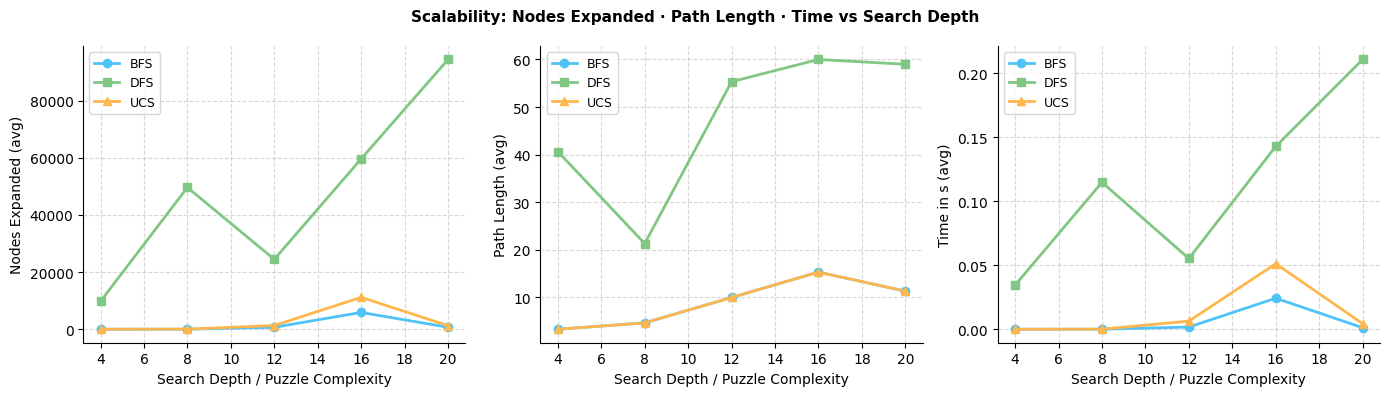

In [14]:
# ─── Plot scalability ─────────────────────────────────────────────────────────
import statistics

algo_names = ["BFS", "DFS", "UCS"]
palette    = {"BFS": "#4fc3f7", "DFS": "#81c784", "UCS": "#ffb74d"}
markers    = {"BFS": "o", "DFS": "s", "UCS": "^"}

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Scalability: Nodes Expanded · Path Length · Time vs Search Depth",
             fontsize=11, fontweight="bold")

for algo in algo_names:
    # Collect per-depth means
    means_nodes, means_path, means_time = [], [], []
    for d in depths:
        subset_n = [data["nodes_expanded"][i]
                    for i in range(len(data["depth"]))
                    if data["depth"][i] == d and data["algo"][i] == algo]
        subset_p = [data["path_len"][i]
                    for i in range(len(data["depth"]))
                    if data["depth"][i] == d and data["algo"][i] == algo and data["path_len"][i] >= 0]
        subset_t = [data["time_s"][i]
                    for i in range(len(data["depth"]))
                    if data["depth"][i] == d and data["algo"][i] == algo]

        means_nodes.append(statistics.mean(subset_n) if subset_n else 0)
        means_path.append(statistics.mean(subset_p) if subset_p else 0)
        means_time.append(statistics.mean(subset_t) if subset_t else 0)

    kw = dict(color=palette[algo], marker=markers[algo], linewidth=2, markersize=6, label=algo)
    axes[0].plot(depths, means_nodes, **kw)
    axes[1].plot(depths, means_path,  **kw)
    axes[2].plot(depths, means_time,  **kw)

for ax, ylabel in zip(axes, ["Nodes Expanded (avg)", "Path Length (avg)", "Time in s (avg)"]):
    ax.set_xlabel("Search Depth / Puzzle Complexity")
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.5)
    ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()


---
## Part 7 — Summary & Key Takeaways

| Property | BFS | DFS | UCS |
|---|---|---|---|
| Data structure | Queue (FIFO) | Stack (LIFO) | Min-heap |
| Completeness | ✅ Yes | ⚠️ With depth limit | ✅ Yes |
| Optimality | ✅ Shortest path | ❌ No | ✅ Min-cost path |
| Time complexity | $O(b^d)$ | $O(b^m)$ | $O(b^{1+\lfloor C^*/\varepsilon\rfloor})$ |
| Space complexity | $O(b^d)$ | $O(b \cdot m)$ | $O(b^{1+\lfloor C^*/\varepsilon\rfloor})$ |
| Best use case | Shallow solutions | Memory-constrained | Non-uniform step costs |

### When to choose which algorithm?
- **BFS** — when you need the guaranteed shortest solution and memory is not a constraint
- **DFS** — when memory is limited or you just need *any* valid solution quickly (not necessarily shortest)  
- **UCS** — when step costs vary (e.g., different tiles have different move costs); generalises BFS

### Next steps
- Try **Iterative Deepening DFS (IDDFS)** — combines BFS optimality with DFS space efficiency  
- Add **heuristics** → A* search (informed search, much faster for hard puzzles)  
- Extend to the **15-puzzle** (4×4) where uninformed search becomes impractical
